# OIBSIP Task 4 - Email Spam Detection with Machine Learning

## Project Overview

This project was completed as part of the Oasis Infobyte Data Science Internship (OIBSIP).

The goal of this project is to build a machine learning model that can classify messages as either spam or legitimate messages (ham).

The project uses text preprocessing, TF-IDF vectorization, machine learning classification models, and evaluation metrics to identify spam messages.

## Objective

The main objective of this project is to develop a machine learning classifier that can identify whether a message is spam or ham.

The project focuses on:

- Loading and understanding the dataset
- Cleaning and preparing the text data
- Exploring the distribution of spam and ham messages
- Converting text into numerical features using TF-IDF
- Training different classification models
- Evaluating model performance
- Comparing the models
- Selecting the best-performing model
- Testing the final model on new messages

## 1. Import Libraries

The libraries below are used for data handling, text preprocessing, visualization, machine learning, and model evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)

In [4]:
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

The spam dataset is loaded using Pandas so that the messages and their labels can be examined before preprocessing.

In [8]:
import pandas as pd

file_path = r"C:\Users\rrama_t5uaug6\Downloads\archive (4)\spam.csv"

df = pd.read_csv(file_path, encoding="latin-1")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3. Dataset Overview

The dataset is inspected to understand its number of records, columns, data types, and overall structure.

In [9]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(5572, 5)

Column Names:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [10]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN



Last 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


## 5. Clean the Dataset

The dataset contains three additional unnamed columns that are mostly empty. These columns are not required for spam classification, so they are removed.

The remaining columns are renamed to make the dataset easier to understand and work with.

In [11]:
# Remove unnecessary columns
df = df[["v1", "v2"]]

# Rename columns
df = df.rename(columns={
    "v1": "Label",
    "v2": "Message"
})

print("Dataset cleaned successfully.")
df.head()

Dataset cleaned successfully.


,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 6. Check for Missing Values

Missing values are checked to make sure that the label and message columns contain valid information before continuing with text preprocessing.

In [13]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Label      0
Message    0
dtype: int64


## 7. Check for Duplicate Messages

Duplicate messages are checked because repeated records can affect the analysis and model training.

In [14]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
403


## 8. Remove Duplicate Messages

The dataset contains duplicate messages. These duplicate records are removed to reduce repetition in the training data and help prevent the model from being overly influenced by repeated examples.

In [15]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates removed successfully.")
print("New dataset shape:", df.shape)

Duplicates removed successfully.
New dataset shape: (5169, 2)


## 9. Spam and Ham Distribution

The distribution of spam and ham messages is examined to understand the class balance in the dataset.

In [16]:
print("Message label counts:")
print(df["Label"].value_counts())

Message label counts:
Label
ham     4516
spam     653
Name: count, dtype: int64


In [17]:
print("\nMessage label percentages:")
print((df["Label"].value_counts(normalize=True) * 100).round(2))


Message label percentages:
Label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


## 10. Spam vs Ham Visualization

A bar chart is created to visually compare the number of spam and ham messages in the dataset.

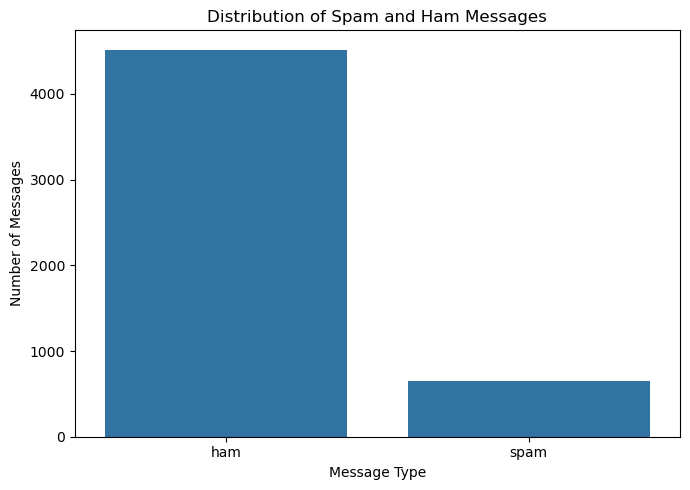

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Label")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.tight_layout()
plt.show()

### Observation

The dataset contains substantially more ham messages than spam messages. This shows that the dataset is imbalanced, with legitimate messages representing the majority of the records and spam messages making up a smaller portion. This class distribution should be considered when evaluating the machine learning models.

## 11. Message Length Analysis

The length of each message is calculated to compare the characteristics of spam and ham messages.

In [19]:
# Calculate the number of characters in each message
df["Message_Length"] = df["Message"].str.len()

print("Message length statistics:")
print(df["Message_Length"].describe())

Message length statistics:
count    5169.000000
mean       78.977945
std        58.236293
min         2.000000
25%        36.000000
50%        60.000000
75%       117.000000
max       910.000000
Name: Message_Length, dtype: float64


In [20]:
print("Average message length by type:")
print(df.groupby("Label")["Message_Length"].mean().round(2))

Average message length by type:
Label
ham      70.46
spam    137.89
Name: Message_Length, dtype: float64


## 12. Message Length by Message Type

The distribution of message length is compared between ham and spam messages to identify differences in their text characteristics.

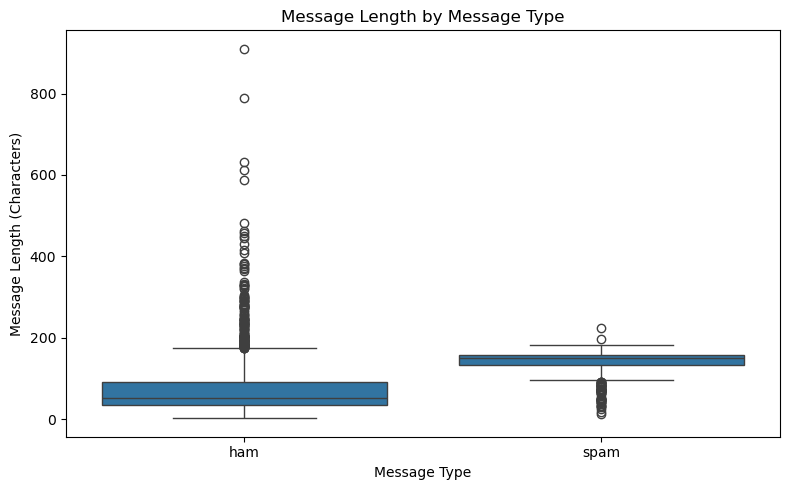

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Label",
    y="Message_Length"
)

plt.title("Message Length by Message Type")
plt.xlabel("Message Type")
plt.ylabel("Message Length (Characters)")

plt.tight_layout()
plt.show()

### Observation

Spam messages generally have greater message lengths than ham messages. The average spam message length is approximately 137.89 characters, compared with approximately 70.46 characters for ham messages. This suggests that message length may provide useful information for distinguishing between spam and legitimate messages.

## 13. Convert Labels to Numerical Values

Machine learning models require numerical target values. Therefore, the message labels are converted into numerical form, where ham is represented by 0 and spam is represented by 1.

In [22]:
# Convert message labels to numerical values
df["Label_Numeric"] = df["Label"].map({
    "ham": 0,
    "spam": 1
})

print("Label conversion completed.")
print(df[["Label", "Label_Numeric"]].head())

Label conversion completed.
  Label  Label_Numeric
0   ham              0
1   ham              0
2  spam              1
3   ham              0
4   ham              0


## 14. Text Preprocessing

The message text is cleaned before feature extraction. The text is converted to lowercase and punctuation and unnecessary characters are removed. This helps create a more consistent representation of the messages for machine learning.

In [23]:
import re

def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df["Clean_Message"] = df["Message"].apply(clean_text)

print("Text preprocessing completed.")
display(df[["Message", "Clean_Message"]].head())

Text preprocessing completed.


,Message,Clean_Message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## 15. Review Cleaned Text

A few original and cleaned messages are displayed to verify that the preprocessing has been applied correctly.

In [24]:
display(df[["Label", "Message", "Clean_Message"]].head(10))

,Label,Message,Clean_Message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been 3 weeks now...
6,ham,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,ham,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,spam,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,spam,Had your mobile 11 months or more? U R entitle...,had your mobile 11 months or more u r entitled...


## 16. Train-Test Split

The dataset is divided into training and testing sets before TF-IDF vectorization. The training data is used to learn the text features, while the testing data is kept separate for evaluating the trained models.

In [27]:
# Define the input text and target variable
X_text = df["Clean_Message"]
y = df["Label_Numeric"]

# Split the data into training and testing sets
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 4135
Testing samples: 1034


## 17. TF-IDF Feature Extraction

TF-IDF is used to convert the cleaned text messages into numerical features.

The vectorizer is fitted only on the training messages and then used to transform both the training and testing messages. This prevents information from the testing data from being used during training.

In [28]:
# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english")

# Learn TF-IDF features from training data
X_train = tfidf.fit_transform(X_train_text)

# Transform the test data using the same vectorizer
X_test = tfidf.transform(X_test_text)

print("TF-IDF vectorization completed.")
print("Training feature matrix shape:", X_train.shape)
print("Testing feature matrix shape:", X_test.shape)

TF-IDF vectorization completed.
Training feature matrix shape: (4135, 5000)
Testing feature matrix shape: (1034, 5000)


## 18. Class Distribution After Train-Test Split

The class distribution in the training and testing sets is checked to confirm that both sets contain representative proportions of ham and spam messages.

In [31]:
print("Training set distribution:")
print(y_train.value_counts())

print("\nTesting set distribution:")
print(y_test.value_counts())

Training set distribution:
Label_Numeric
0    3613
1     522
Name: count, dtype: int64

Testing set distribution:
Label_Numeric
0    903
1    131
Name: count, dtype: int64


## 19. Train Machine Learning Models

Three classification models are trained to identify spam and ham messages. Logistic Regression, Multinomial Naive Bayes, and Random Forest are selected to compare different machine learning approaches for text classification.

In [32]:
# Create the machine learning models

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42)

naive_bayes_model = MultinomialNB()

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1)

# Train the models
logistic_model.fit(X_train, y_train)
naive_bayes_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


## 20. Generate Predictions

The trained models are used to predict the labels of the unseen testing messages. These predictions will be compared with the actual labels to evaluate model performance.

In [34]:
# Generate predictions for the test set

logistic_pred = logistic_model.predict(X_test)
naive_bayes_pred = naive_bayes_model.predict(X_test)
random_forest_pred = random_forest_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


## 21. Model Evaluation

The models are evaluated using accuracy, precision, recall, and F1-score. These metrics provide a more complete view of model performance, particularly because the dataset contains substantially more ham messages than spam messages.

In [35]:
# Calculate evaluation metrics

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, naive_bayes_pred),
        accuracy_score(y_test, random_forest_pred)],
    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, naive_bayes_pred),
        precision_score(y_test, random_forest_pred)],
    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, naive_bayes_pred),
        recall_score(y_test, random_forest_pred)],
    "F1 Score": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, naive_bayes_pred),
        f1_score(y_test, random_forest_pred)]})

results = results.round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9787,0.9360,0.8931,0.9141
1,Multinomial Naive Bayes,0.9681,0.9804,0.7634,0.8584
2,Random Forest,0.9710,0.9810,0.7863,0.8729


## 22. Classification Reports

Classification reports are generated for each model to examine precision, recall, and F1-score separately for ham and spam messages.

In [36]:
print("Logistic Regression Classification Report")
print(classification_report(
    y_test,
    logistic_pred,
    target_names=["Ham", "Spam"]))

print("\nMultinomial Naive Bayes Classification Report")
print(classification_report(
    y_test,
    naive_bayes_pred,
    target_names=["Ham", "Spam"]))

print("\nRandom Forest Classification Report")
print(classification_report(
    y_test,
    random_forest_pred,
    target_names=["Ham", "Spam"]))

Logistic Regression Classification Report
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.94      0.89      0.91       131

    accuracy                           0.98      1034
   macro avg       0.96      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034


Multinomial Naive Bayes Classification Report
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       0.98      0.76      0.86       131

    accuracy                           0.97      1034
   macro avg       0.97      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034


Random Forest Classification Report
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       0.98      0.79      0.87       131

    accuracy                           0.97      1034
  

### Observation

Logistic Regression achieved the best overall performance among the three models, with an accuracy of 98%, spam precision of 0.94, spam recall of 0.89, and spam F1-score of 0.91.

Multinomial Naive Bayes and Random Forest achieved an accuracy of approximately 97%. Although both models achieved higher spam precision of 0.98, their spam recall was lower at 0.76 and 0.79 respectively.

Since spam recall is important for identifying as many actual spam messages as possible, Logistic Regression provides the best overall balance for this dataset.

## 23. Confusion Matrix

Confusion matrices are used to examine the correct and incorrect predictions made by each classification model. They show how many ham and spam messages were classified correctly and how many were misclassified.

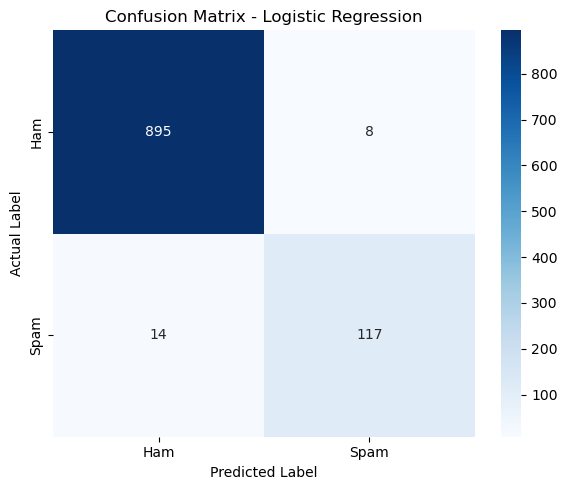

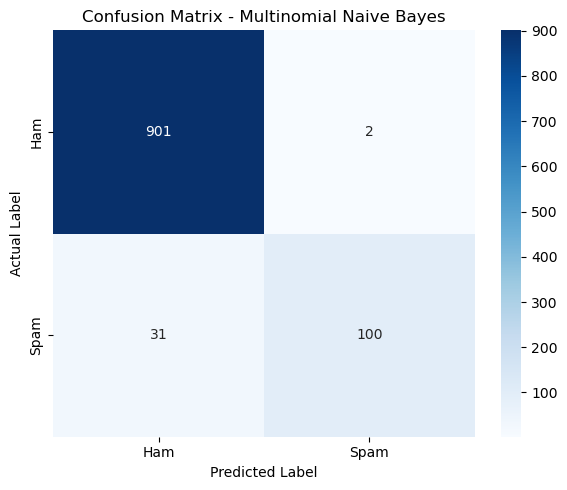

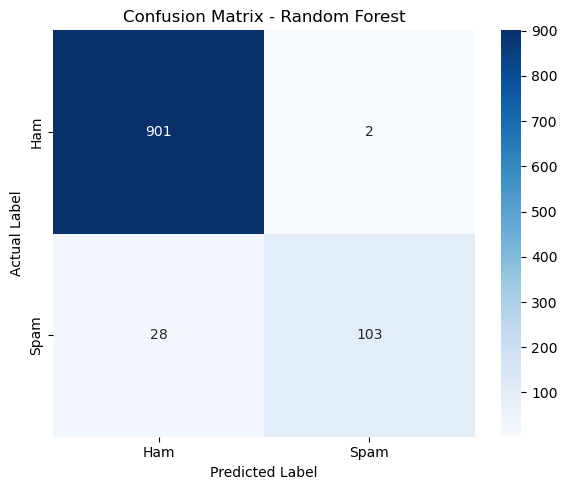

In [37]:
# Create confusion matrices for all three models

models_predictions = {
    "Logistic Regression": logistic_pred,
    "Multinomial Naive Bayes": naive_bayes_pred,
    "Random Forest": random_forest_pred}

for model_name, predictions in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Ham", "Spam"],
        yticklabels=["Ham", "Spam"])

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()

## 24. Select the Best Performing Model

The models are compared using their F1-scores. The model with the highest F1-score is selected as the final spam detection model.

In [39]:
# Select the model with the highest F1-score

best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"]

print("Best performing model:", best_model_name)

Best performing model: Logistic Regression


## 25. Final Model

Logistic Regression is selected as the final model because it achieved the highest F1-score among the tested models.

In [41]:
# Store the best model
best_model = logistic_model

print("Final model selected:", best_model_name)

Final model selected: Logistic Regression


## 26. Test the Model with New Messages

The final Logistic Regression model is tested on new messages that were not part of the original dataset. This provides a practical demonstration of how the spam detection system can classify unseen messages.

In [42]:
# Create new messages for testing
new_messages = [
    "Congratulations! You have won a free prize. Call now to claim your reward!",
    "Hey, are you coming to class tomorrow?",
    "URGENT! You have been selected for a cash prize. Reply now!",
    "Can you send me the meeting details when you get a chance?",
    "You have won a free vacation. Click here to claim your prize."]

# Clean the new messages
clean_new_messages = [clean_text(message) for message in new_messages]

# Convert the messages using the trained TF-IDF vectorizer
new_messages_tfidf = tfidf.transform(clean_new_messages)

# Predict using the final Logistic Regression model
new_predictions = best_model.predict(new_messages_tfidf)

# Display the predictions
prediction_results = pd.DataFrame({
    "Message": new_messages,
    "Prediction": [
        "Spam" if prediction == 1 else "Ham"
        for prediction in new_predictions]})

display(prediction_results)

,Message,Prediction
0,Congratulations! You have won a free prize. Ca...,Ham
1,"Hey, are you coming to class tomorrow?",Ham
2,URGENT! You have been selected for a cash priz...,Spam
3,Can you send me the meeting details when you g...,Ham
4,You have won a free vacation. Click here to cl...,Ham


## 27. Custom Message Prediction

A helper function is created to classify an individual message as spam or ham using the final trained model.

In [44]:
def predict_spam(message):
    # Clean the message
    cleaned_message = clean_text(message)
    
    # Convert the message into TF-IDF features
    message_tfidf = tfidf.transform([cleaned_message])
    
    # Make the prediction
    prediction = best_model.predict(message_tfidf)[0]
    
    if prediction == 1:
        return "Spam"
    else:
        return "Ham"

In [46]:
test_message = "Congratulations! You have won a free cash prize. Claim now!"

print("Message:", test_message)
print("Prediction:", predict_spam(test_message))

Message: Congratulations! You have won a free cash prize. Claim now!
Prediction: Ham


In [47]:
test_message = "Hi, are we still meeting for lunch today?"

print("Message:", test_message)
print("Prediction:", predict_spam(test_message))

Message: Hi, are we still meeting for lunch today?
Prediction: Ham


## 28. Prediction Confidence

The prediction probability is examined for custom messages to understand how confident the Logistic Regression model is in its classification.

In [48]:
def predict_spam_with_probability(message):
    # Clean the message
    cleaned_message = clean_text(message)

    # Convert the message using the trained TF-IDF vectorizer
    message_tfidf = tfidf.transform([cleaned_message])

    # Get prediction probabilities
    probabilities = best_model.predict_proba(message_tfidf)[0]

    prediction = best_model.predict(message_tfidf)[0]

    if prediction == 1:
        label = "Spam"
    else:
        label = "Ham"

    return label, probabilities[1]


test_messages = [
    "Congratulations! You have won a free cash prize. Claim now!",
    "Hi, are we still meeting for lunch today?"]

for message in test_messages:
    prediction, spam_probability = predict_spam_with_probability(message)

    print("Message:", message)
    print("Prediction:", prediction)
    print("Spam probability:", round(spam_probability * 100, 2), "%")
    print()

Message: Congratulations! You have won a free cash prize. Claim now!
Prediction: Ham
Spam probability: 22.58 %

Message: Hi, are we still meeting for lunch today?
Prediction: Ham
Spam probability: 25.34 %



## 29. Logistic Regression Confusion Matrix

The confusion matrix for the final Logistic Regression model is examined to understand how many ham and spam messages were classified correctly and incorrectly.

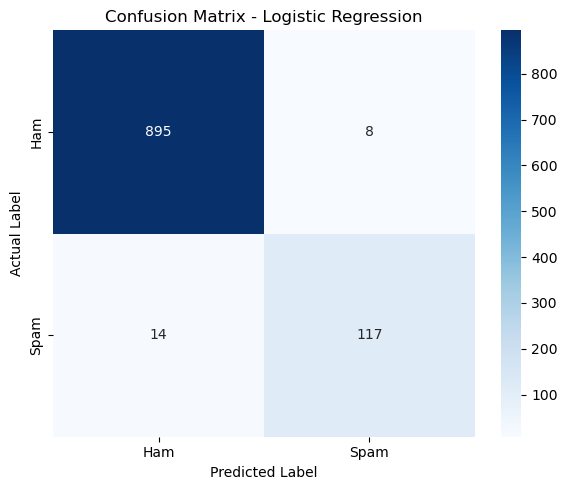

In [49]:
cm = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"])

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

### Observation

The Logistic Regression confusion matrix shows that 895 ham messages and 117 spam messages were classified correctly. The model incorrectly classified 8 ham messages as spam and missed 14 actual spam messages. Overall, the model performs well, although some spam messages are still misclassified as ham.

## 30. Model Performance Comparison

The performance of the three classification models is compared using accuracy, precision, recall, and F1-score. This helps identify which model provides the best overall performance for spam detection.

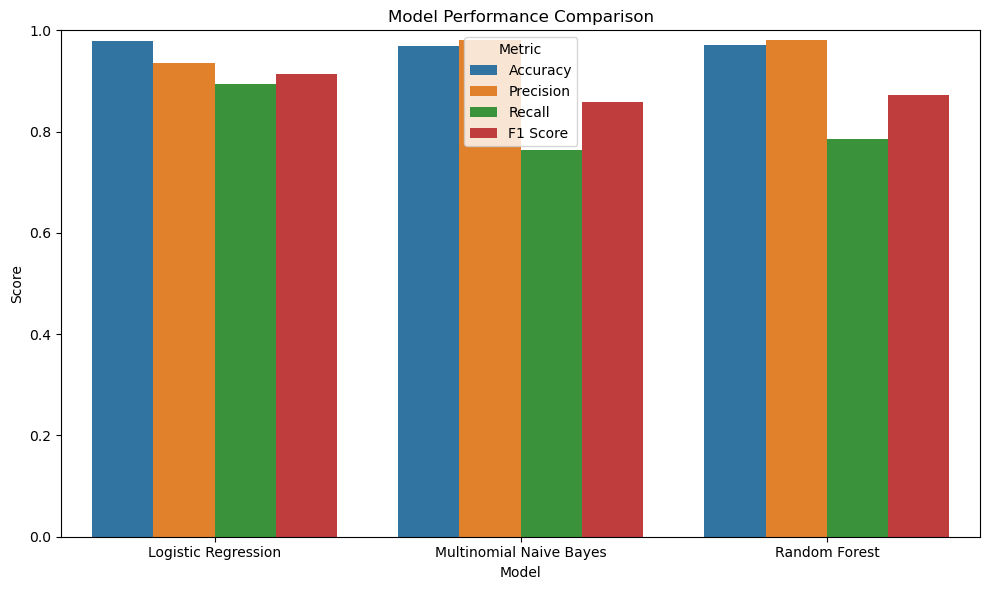

In [50]:
# Reshape the results for visualization
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

results_melted = results.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric")

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## 31. Final Model Summary

Logistic Regression was selected as the final model because it achieved the highest F1-score among the three tested models. It provided a strong balance between precision and recall for detecting spam messages.

In [51]:
# Display the final model performance

final_result = results[
    results["Model"] == best_model_name]

display(final_result)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9787,0.936,0.8931,0.9141


## 32. Key Findings

- The cleaned dataset contains 5,169 messages after removing 403 duplicate records.
- The dataset contains substantially more ham messages than spam messages.
- Spam messages have a higher average length than ham messages in this dataset.
- The average spam message length is approximately 137.89 characters, compared with 70.46 characters for ham messages.
- TF-IDF was used to convert message text into numerical features.
- Logistic Regression, Multinomial Naive Bayes, and Random Forest were tested.
- Logistic Regression achieved the highest overall accuracy of approximately 98%.
- Logistic Regression achieved a spam precision of 0.94, spam recall of 0.89, and spam F1-score of 0.91.
- The Logistic Regression confusion matrix shows 117 correctly detected spam messages and 14 missed spam messages in the test set.
- Custom message testing showed that the model can classify normal messages as ham, but some spam-like unseen messages may still be misclassified.

## 33. Conclusion

This project developed a machine learning model for detecting spam messages using natural language processing and TF-IDF feature extraction.

After cleaning the dataset and removing 403 duplicate records, 5,169 messages were used for analysis. The dataset contained considerably more ham messages than spam messages.

Three machine learning models were evaluated: Logistic Regression, Multinomial Naive Bayes, and Random Forest. Logistic Regression achieved the best overall performance with an accuracy of 97.87%, precision of 93.60%, recall of 89.31%, and F1-score of 91.41%.

The confusion matrix showed that the model correctly classified 117 out of 131 spam messages in the test set, while 14 spam messages were classified as ham.

Testing with new messages also demonstrated that the model can classify unseen messages, although individual messages may still be misclassified. This highlights the importance of evaluating a spam detection system using multiple performance metrics rather than accuracy alone.

Overall, the project demonstrates how text preprocessing, TF-IDF feature extraction, and machine learning can be combined to build an effective spam detection system.

## 34. Limitations

- The dataset contains substantially more ham messages than spam messages.
- The model can still misclassify some spam messages as ham.
- The model is trained on a specific SMS spam dataset and may not perform the same way on messages from different sources.
- New spam techniques and unfamiliar wording may affect model performance.
- The model relies on the vocabulary learned from the training dataset.